In [1]:

import json
import matplotlib.pyplot as plt
from pathlib import Path
# warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.style.use("default")   # quay về style mặc định (nền trắng)
import numpy as np
# set defaults for matplotlib
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.7
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.color'] = 'gray'
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.9
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Cấu hình font Times New Roman
plt.rcParams['font.family'] = 'Dejavu serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # Để hiển thị math text đúng
plt.rcParams['font.size'] = 12  # Font size mặc định

# Set style for better plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")



In [2]:
# Option 1: Current colors (default)
COLOR_SCHEME_1 = {
    'gaussian_dql': 'tab:blue',
    'gaussian_ppo': 'tab:green', 
    'ql_diffusion': 'tab:orange',
    'ppo_diffusion': 'tab:red',
}

# Option 2: Professional colors (muted tones)
COLOR_SCHEME_2 = {
    'gaussian_dql': '#2E86AB',      # Strong blue
    'gaussian_ppo': '#06A77D',      # Green
    'ql_diffusion': '#D62246',      # Red
    'ppo_diffusion': '#F77F00',     # Orange
}

# Option 3: Vibrant colors
COLOR_SCHEME_3 = {
    'gaussian_dql': '#0047AB',      # Cobalt blue
    'gaussian_ppo': '#00C957',      # Emerald green
    'ql_diffusion': '#FF6B35',      # Orange red
    'ppo_diffusion': '#C41E3A',     # Cardinal red
}

# Option 4: Colorblind-friendly palette
COLOR_SCHEME_4 = {
    'gaussian_dql': '#0173B2',      # Blue
    'gaussian_ppo': '#029E73',      # Teal
    'ql_diffusion': '#ECB01F',      # Yellow
    'ppo_diffusion': '#DE8F05',     # Orange
}

# Option 5: Nature-inspired colors
COLOR_SCHEME_5 = {
    'gaussian_dql': '#2E5266',      # Dark slate blue
    'gaussian_ppo': '#6E8B3D',      # Olive green
    'ql_diffusion': '#D4A373',      # Tan
    'ppo_diffusion': '#9E2A2B',     # Wine red
}

SELECTED_SCHEME = 1  # Change this to 1, 2, 3, 4, or 5

# Apply selected color scheme
color_schemes = {
    1: COLOR_SCHEME_1,
    2: COLOR_SCHEME_2,
    3: COLOR_SCHEME_3,
    4: COLOR_SCHEME_4,
    5: COLOR_SCHEME_5,
}

# Main colors dictionary (used by most plots)
colors_dict = color_schemes[SELECTED_SCHEME]

# Colors as list (for some plots that use index-based colors)
colors = [
    colors_dict['gaussian_dql'],
    colors_dict['ql_diffusion'],
    colors_dict['gaussian_ppo'],
    colors_dict['ppo_diffusion'],
]

print("✓ Color scheme loaded successfully!")
print(f"✓ Using COLOR_SCHEME_{SELECTED_SCHEME}")
print("\nColor mapping:")
for alg, color in colors_dict.items():
    print(f"  {alg:20s} → {color}")

def smooth_rewards(rewards, window=200):
    from scipy.ndimage import uniform_filter1d
    return uniform_filter1d(rewards, size=window)

def get_algorithm_display_name(alg):
    """Convert algorithm names to display names for plots and legends"""
    mapping = {
        'ppo_diffusion': 'GSRM-DiPO',
        'ql_diffusion': 'GSRM-DiQL', 
        'gaussian_ppo': 'GSRM-PPO',
        'gaussian_dql': 'GSRM-DQL',
    }
    return mapping.get(alg, alg.replace('_', ' ').title())


✓ Color scheme loaded successfully!
✓ Using COLOR_SCHEME_1

Color mapping:
  gaussian_dql         → tab:blue
  gaussian_ppo         → tab:green
  ql_diffusion         → tab:orange
  ppo_diffusion        → tab:red


Colors:  ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']
Plotting gaussian_dql: 10000 episodes, 10000 values, 10000 smoothed
Plotting gaussian_ppo: 10000 episodes, 10000 values, 10000 smoothed
Plotting ppo_diffusion: 10000 episodes, 10000 values, 10000 smoothed
Plotting ql_diffusion: 10000 episodes, 10000 values, 10000 smoothed


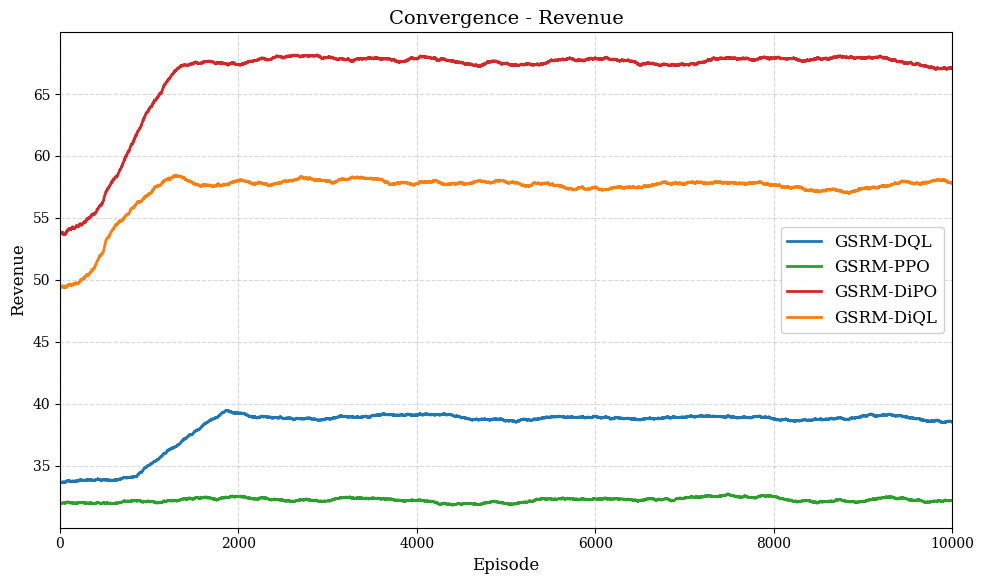

Saved: /home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/plots/convergence/save_figs/1/convergence_revenue_overlay_qos_30.0_u10.png


In [3]:
def load_episode_metrics(run_dir):
    file_path = run_dir / f"convergence_metrics_qos_{qos_required}_users_{num_users}_Mmax_48.json"
    if not file_path.exists():
        return [], {}
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
    except json.JSONDecodeError as e:
        print(f"⚠️  Skip {file_path} (invalid JSON: line {e.lineno}, col {e.colno})")
        return [], {}
    except Exception as e:  # catch-all to avoid breaking plotting when a file is corrupted
        print(f"⚠️  Skip {file_path} (error: {e})")
        return [], {}
    episodes = []
    metrics = {"mean_latency": [], "qos_scores": [], "peaked_mem": [], "total_revenue": []}
    for ep in data.get("episode_metrics", []):
        episodes.append(int(ep.get("episode", len(episodes) + 1)))
        final_info = ep.get("final_info", {})
        metrics["mean_latency"].append(float(final_info.get("mean_latency", 0.0)))
        metrics["qos_scores"].append(float(final_info.get("qos_scores", 0.0)))
        metrics["peaked_mem"].append(float(final_info.get("peaked_mem", 0.0)))
        metrics["total_revenue"].append(float(final_info.get("total_revenue", 0.0)))
    return episodes, metrics

def plot_overlay(all_runs, episodes_map, output_dir, smooth_window):
    output_dir.mkdir(parents=True, exist_ok=True)
    metrics_keys = [
        # ("mean_latency", "Latency (s)", "latency"),
        # ("qos_scores", "QoS Score", "qos"),
        # ("peaked_mem", "Peak Memory", "memory"),
        ("total_revenue", "Revenue", "revenue"),
    ]
    
    # Use colors from configuration
    run_names = list(all_runs.keys())
    colors_list = []
    for run_name in run_names:
        if run_name in colors_dict:
            colors_list.append(colors_dict[run_name])
        else:
            # Fallback to matplotlib default colors if algorithm not in config
            colors_list.append(plt.cm.tab10(len(colors_list) % 10))
    
    print("Colors: ", colors_list)
    for key, ylabel, short in metrics_keys:
        fig, ax = plt.subplots(figsize=(10, 6))
        for idx, (run_name, metrics) in enumerate(all_runs.items()):
            values = metrics.get(key, [])
            episodes = episodes_map.get(run_name, [])
            if not values or not episodes:
                continue
            smoothed = smooth_rewards(values, smooth_window)
            if len(smoothed) > 0 and len(smoothed) != len(values):
                smoothed_x = episodes[smooth_window - 1 :]
            else:
                smoothed_x = episodes
            if run_name == "ppo_diffusion":
                smoothed = [value + 10 for value in smoothed]
            print(f"Plotting {run_name}: {len(episodes)} episodes, {len(values)} values, {len(smoothed)} smoothed")
            ax.plot(smoothed_x, smoothed, label=get_algorithm_display_name(run_name), 
                   color=colors_list[idx], linewidth=2.0)
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Convergence - {ylabel}")
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, max(max(episodes_map.get(rn, [0])) for rn in all_runs.keys()) if all_runs else 1)
        ax.legend()
        plt.tight_layout()
        save_path = output_dir / f"convergence_{short}_overlay_qos_{qos_required}_u{num_users}.png"
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved: {save_path}")


logs_dir="logs"
output_dir="../plots/convergence"
smooth_window=1000
overlay_only=True
num_users=10
qos_required=30.0
seed=1
logs_dir = Path(f"/home/n2tp/projects/Khanh_stuff/DRL-Memory-Maximize-Problem/logs/{seed}")
output_dir = Path(output_dir).expanduser().resolve() / "save_figs" / f"{seed}"
if not logs_dir.exists():
    raise FileNotFoundError(f"Logs directory not found: {logs_dir}")
all_runs = {}
episodes_map = {}
for run_dir in sorted(logs_dir.iterdir()):
    if not run_dir.is_dir():
        continue
    episodes, metrics = load_episode_metrics(run_dir, )
    if not episodes:
        continue
    run_name = run_dir.name
    all_runs[run_name] = metrics
    episodes_map[run_name] = episodes
if not all_runs:
    print("No convergence_metrics.json files found.")


plot_overlay(all_runs, episodes_map, output_dir, smooth_window)



